In [8]:
# Importações necessárias

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') # Melhorar visualização dos gráficos

In [9]:
def bissecao(f, a, b, tol=1e-5, max_iter=100):
    """
    Implementa o método da Bisseção para encontrar raízes de f(x) no intervalo [a, b].
    Baseado no Algoritmo 1.1 do texto.
    """
    # Verificar a existência da raiz (Teorema do Valor Intermediário)
    # Usa np.sign para evitar overflow conforme sugerido no texto
    if np.sign(f(a)) * np.sign(f(b)) != -1:
        print("Erro: Não há garantia de raiz no intervalo (sinais iguais nos extremos).")
        return None

    iteracoes = []

    ai, bi = a, b
    xi = a # Valor inicial apenas para cálculo do erro na primeira iteração

    print(f"{'Iter':<5} | {'a':<10} | {'b':<10} | {'x_mid':<10} | {'f(x_mid)':<10} | {'Erro (%)':<10}")

    for i in range(max_iter):
        # Calcular ponto médio
        xi_old = xi
        xi = (ai + bi) / 2

        # Cálculo do erro relativo (se não for a primeira iteração)
        erro = 0
        if i > 0:
            erro = np.abs((xi - xi_old) / xi) * 100

        fx = f(xi)
        iteracoes.append((i+1, ai, bi, xi, fx, erro))
        print(f"{i+1:<5} | {ai:.6f}   | {bi:.6f}   | {xi:.6f}   | {fx:.6f}   | {erro:.4f}%")

        # Verificar se encontrou a raiz exata ou atingiu a tolerância
        if fx == 0 or (i > 0 and erro < tol):
            return xi

        # Passo 5: Verificar subintervalo
        if np.sign(f(ai)) * np.sign(fx) == -1:
            bi = xi # Raiz está no primeiro subintervalo [ai, xi]
        else:
            ai = xi # Raiz está no segundo subintervalo [xi, bi]

    return xi

In [10]:
f_teste = lambda x: 2 - np.exp(x)
raiz = bissecao(f_teste, 0, 1, tol=1e-2)
print(f"\nRaiz encontrada: {raiz:.6f}")

Iter  | a          | b          | x_mid      | f(x_mid)   | Erro (%)  
1     | 0.000000   | 1.000000   | 0.500000   | 0.351279   | 0.0000%
2     | 0.500000   | 1.000000   | 0.750000   | -0.117000   | 33.3333%
3     | 0.500000   | 0.750000   | 0.625000   | 0.131754   | 20.0000%
4     | 0.625000   | 0.750000   | 0.687500   | 0.011263   | 9.0909%
5     | 0.687500   | 0.750000   | 0.718750   | -0.051867   | 4.3478%
6     | 0.687500   | 0.718750   | 0.703125   | -0.020056   | 2.2222%
7     | 0.687500   | 0.703125   | 0.695312   | -0.004335   | 1.1236%
8     | 0.687500   | 0.695312   | 0.691406   | 0.003479   | 0.5650%
9     | 0.691406   | 0.695312   | 0.693359   | -0.000424   | 0.2817%
10    | 0.691406   | 0.693359   | 0.692383   | 0.001528   | 0.1410%
11    | 0.692383   | 0.693359   | 0.692871   | 0.000552   | 0.0705%
12    | 0.692871   | 0.693359   | 0.693115   | 0.000064   | 0.0352%
13    | 0.693115   | 0.693359   | 0.693237   | -0.000180   | 0.0176%
14    | 0.693115   | 0.693237   | 0.6

Questão 2

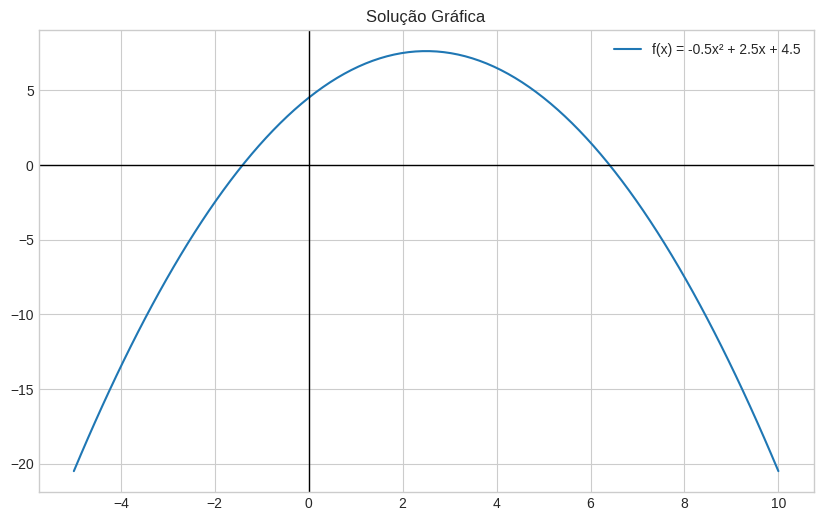

Raízes Reais (Analíticas): -1.405125 e 6.405125

Cálculo Manual (3 Iterações):
Iter 1: xl=5.0, xu=10.0, xr=7.5, f(xr)=-4.8750
        Erro Relativo Aprox: 0.0000%, Erro Verdadeiro: 17.0937%
Iter 2: xl=5.0, xu=7.5, xr=6.25, f(xr)=0.5938
        Erro Relativo Aprox: 20.0000%, Erro Verdadeiro: 2.4219%
Iter 3: xl=6.25, xu=7.5, xr=6.875, f(xr)=-1.9453
        Erro Relativo Aprox: 9.0909%, Erro Verdadeiro: 7.3359%


In [11]:
# Definição da função
def f2(x):
    return -0.5 * x**2 + 2.5 * x + 4.5

# ITEM A
x = np.linspace(-5, 10, 100)
y = f2(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = -0.5x² + 2.5x + 4.5')
plt.axhline(0, color='black', linewidth=1) # Eixo X
plt.axvline(0, color='black', linewidth=1) # Eixo Y
plt.title('Solução Gráfica')
plt.grid(True)
plt.legend()
plt.show()

# ITEM B
# ax^2 + bx + c = 0
a, b, c = -0.5, 2.5, 4.5
delta = b**2 - 4*a*c
raiz_real_1 = (-b + np.sqrt(delta)) / (2*a)
raiz_real_2 = (-b - np.sqrt(delta)) / (2*a)

print(f"Raízes Reais (Analíticas): {raiz_real_1:.6f} e {raiz_real_2:.6f}")
maior_raiz_real = max(raiz_real_1, raiz_real_2)

# ITEM C
# Intervalo [5, 10]
xl, xu = 5.0, 10.0
iteracoes_q2 = []

print("\nCálculo Manual (3 Iterações):")
x_old = None

for i in range(3):
    xr = (xl + xu) / 2
    f_xl = f2(xl)
    f_xr = f2(xr)

    # Erro relativo aproximado
    ea = np.abs((xr - x_old)/xr) * 100 if x_old is not None else 0
    # Erro verdadeiro
    et = np.abs((maior_raiz_real - xr)/maior_raiz_real) * 100

    print(f"Iter {i+1}: xl={xl}, xu={xu}, xr={xr}, f(xr)={f_xr:.4f}")
    print(f"        Erro Relativo Aprox: {ea:.4f}%, Erro Verdadeiro: {et:.4f}%")

    if f_xl * f_xr < 0:
        xu = xr
    else:
        xl = xr

    x_old = xr

Questão 3

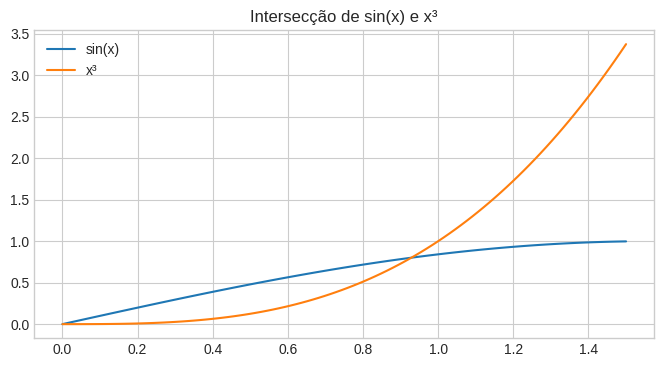

Bisseção para sin(x) = x³:
Iter  | a          | b          | x_mid      | f(x_mid)   | Erro (%)  
1     | 0.500000   | 1.000000   | 0.750000   | 0.259764   | 0.0000%
2     | 0.750000   | 1.000000   | 0.875000   | 0.097622   | 14.2857%
3     | 0.875000   | 1.000000   | 0.937500   | -0.017894   | 6.6667%
4     | 0.875000   | 0.937500   | 0.906250   | 0.042903   | 3.4483%
5     | 0.906250   | 0.937500   | 0.921875   | 0.013277   | 1.6949%
Raiz aproximada: 0.921875


In [12]:
# Função definida
def f3(x):
    return np.sin(x) - x**3

# Gráfico para visualização
x_rad = np.linspace(0, 1.5, 100)
plt.figure(figsize=(8, 4))
plt.plot(x_rad, np.sin(x_rad), label='sin(x)')
plt.plot(x_rad, x_rad**3, label='x³')
plt.title('Intersecção de sin(x) e x³')
plt.legend()
plt.grid(True)
plt.show()

print("Bisseção para sin(x) = x³:")
raiz_f3 = bissecao(f3, 0.5, 1.0, tol=2.0) # tol=2.0 pois o código printa em %
print(f"Raiz aproximada: {raiz_f3}")

Questão 4

In [13]:
# Definindo a derivada
def df4(x):
    return -12 * x**5 - 6 * x**3 + 10

# Buscando a raiz da derivada no intervalo [0, 1] com erro limite de 5%
print("Encontrando máximo via derivada:")
x_max = bissecao(df4, 0, 1, tol=5.0)

# Verificando o valor da função original nesse ponto
def f4(x):
    return -2 * x**6 - 1.5 * x**4 + 10 * x + 20

print(f"O máximo ocorre em x ≈ {x_max:.5f}")
print(f"O valor máximo é f({x_max:.5f}) ≈ {f4(x_max):.5f}")

Encontrando máximo via derivada:
Iter  | a          | b          | x_mid      | f(x_mid)   | Erro (%)  
1     | 0.000000   | 1.000000   | 0.500000   | 8.875000   | 0.0000%
2     | 0.500000   | 1.000000   | 0.750000   | 4.621094   | 33.3333%
3     | 0.750000   | 1.000000   | 0.875000   | -0.174438   | 14.2857%
4     | 0.750000   | 0.875000   | 0.812500   | 2.532627   | 7.6923%
5     | 0.812500   | 0.875000   | 0.843750   | 1.264366   | 3.7037%
O máximo ocorre em x ≈ 0.84375
O valor máximo é f(0.84375) ≈ 26.95564


Questão 5

In [14]:
def falsa_posicao(f, xl, xu, tol=1e-5, max_iter=100):
    """
    Implementa o método da Falsa Posição.
    """
    if np.sign(f(xl)) * np.sign(f(xu)) != -1:
        print("Erro: Sem troca de sinal no intervalo.")
        return None

    print(f"{'Iter':<5} | {'xl':<10} | {'xu':<10} | {'xr':<10} | {'f(xr)':<10} | {'Erro (%)':<10}")

    xr = xl
    for i in range(max_iter):
        xr_old = xr

        # Fórmula da Falsa Posição
        fxl = f(xl)
        fxu = f(xu)
        xr = xu - (fxu * (xl - xu)) / (fxl - fxu)

        erro = 0
        if i > 0:
            erro = np.abs((xr - xr_old) / xr) * 100

        fxr = f(xr)
        print(f"{i+1:<5} | {xl:.6f}   | {xu:.6f}   | {xr:.6f}   | {fxr:.6f}   | {erro:.4f}%")

        if fxr == 0 or (i > 0 and erro < tol):
            return xr, i+1

        if np.sign(fxl) * np.sign(fxr) == -1:
            xu = xr
        else:
            xl = xr

    return xr, max_iter

print("\nComparativo: Bisseção")
bissecao(df4, 0, 1, tol=0.01)

print("\nComparativo: Falsa Posição")
raiz_fp, iter_fp = falsa_posicao(df4, 0, 1, tol=0.01)

print(f"\nRaiz Falsa Posição: {raiz_fp:.6f} em {iter_fp} iterações.")


Comparativo: Bisseção
Iter  | a          | b          | x_mid      | f(x_mid)   | Erro (%)  
1     | 0.000000   | 1.000000   | 0.500000   | 8.875000   | 0.0000%
2     | 0.500000   | 1.000000   | 0.750000   | 4.621094   | 33.3333%
3     | 0.750000   | 1.000000   | 0.875000   | -0.174438   | 14.2857%
4     | 0.750000   | 0.875000   | 0.812500   | 2.532627   | 7.6923%
5     | 0.812500   | 0.875000   | 0.843750   | 1.264366   | 3.7037%
6     | 0.843750   | 0.875000   | 0.859375   | 0.567337   | 1.8182%
7     | 0.859375   | 0.875000   | 0.867188   | 0.202179   | 0.9009%
8     | 0.867188   | 0.875000   | 0.871094   | 0.015320   | 0.4484%
9     | 0.871094   | 0.875000   | 0.873047   | -0.079195   | 0.2237%
10    | 0.871094   | 0.873047   | 0.872070   | -0.031847   | 0.1120%
11    | 0.871094   | 0.872070   | 0.871582   | -0.008241   | 0.0560%
12    | 0.871094   | 0.871582   | 0.871338   | 0.003545   | 0.0280%
13    | 0.871338   | 0.871582   | 0.871460   | -0.002346   | 0.0140%
14    | 0.87133